# 21 · H2 Calibration + H3 Selective Prediction

Using the single best risk model persisted by NB20, this notebook asks two
deployment questions:

- **H2 — is the risk score calibrated?** Uncalibrated vs Platt (sigmoid) vs
  isotonic vs temperature scaling, judged by ECE, adaptive-ECE, MCE and Brier,
  with reliability diagrams.
- **H3 — does selective prediction work?** Risk-coverage curves and AURC / E-AURC
  for model-risk vs raw confidence (MSP) vs oracle vs random, plus coverage and
  accuracy at 1% / 5% / 10% risk budgets.

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, joblib
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from analysis import reliability_metrics as M
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, roc_auc_score
from scipy.optimize import minimize_scalar
OUT = M.OUT_DIR; OUT.mkdir(parents=True, exist_ok=True)

bundle = joblib.load(ROOT / "models" / "voxintel_r_best_risk.joblib")
feats, est = bundle["features"], bundle["estimator"]
print("best risk model:", bundle["model"], "on", bundle["family"], "| features:", feats)

df = M.load_slurp(); tr, te, ytr, yte = M.frozen_split(df)
y = yte.values
p_uncal = est.predict_proba(te[feats])[:, 1]
print(f"uncalibrated held-out: AUC={roc_auc_score(y, p_uncal):.4f} "
      f"Brier={brier_score_loss(y, p_uncal):.4f} ECE={M.ece(y, p_uncal):.4f}")

best risk model: RandomForest on B_intent | features: ['intent_confidence', 'intent_entropy', 'intent_margin']


uncalibrated held-out: AUC=0.8893 Brier=0.1153 ECE=0.1122


## H2 — calibration methods

In [2]:
def mce(y, p, n=15):
    y = np.asarray(y, float); p = np.asarray(p, float); edges = np.linspace(0, 1, n+1); m = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        msk = (p > lo) & (p <= hi) if lo > 0 else (p >= lo) & (p <= hi)
        if msk.any(): m = max(m, abs(y[msk].mean() - p[msk].mean()))
    return float(m)

def temperature(p_tr, y_tr, p_te):
    z = lambda p: np.log(np.clip(p, 1e-6, 1-1e-6) / (1 - np.clip(p, 1e-6, 1-1e-6)))
    ztr, zte = z(p_tr), z(p_te)
    def nll(T):
        q = 1 / (1 + np.exp(-ztr / T)); q = np.clip(q, 1e-9, 1-1e-9)
        return -np.mean(y_tr*np.log(q) + (1-y_tr)*np.log(1-q))
    T = minimize_scalar(nll, bounds=(0.05, 10), method="bounded").x
    return 1 / (1 + np.exp(-zte / T)), float(T)

p_tr = est.predict_proba(tr[feats])[:, 1]
platt = CalibratedClassifierCV(clone(est), method="sigmoid", cv=5).fit(tr[feats], ytr)
iso = CalibratedClassifierCV(clone(est), method="isotonic", cv=5).fit(tr[feats], ytr)
p_temp, T = temperature(p_tr, ytr.values, p_uncal)
CAL = {"uncalibrated": p_uncal, "platt": platt.predict_proba(te[feats])[:, 1],
       "isotonic": iso.predict_proba(te[feats])[:, 1], f"temperature(T={T:.2f})": p_temp}
cal = pd.DataFrame([{"method": k, "ece": M.ece(y, p), "adaptive_ece": M.adaptive_ece(y, p),
                     "mce": mce(y, p), "brier": brier_score_loss(y, p)}
                    for k, p in CAL.items()]).sort_values("ece").reset_index(drop=True)
cal.to_csv(OUT / "nb21_calibration_metrics.csv", index=False)
cal.round(4)

,method,ece,adaptive_ece,mce,brier
0,isotonic,0.0139,0.0147,0.0978,0.0970
1,platt,0.0192,0.0159,0.1622,0.0978
2,temperature(T=0.58),0.0933,0.0969,0.3765,0.1155
3,uncalibrated,0.1122,0.1138,0.2704,0.1153


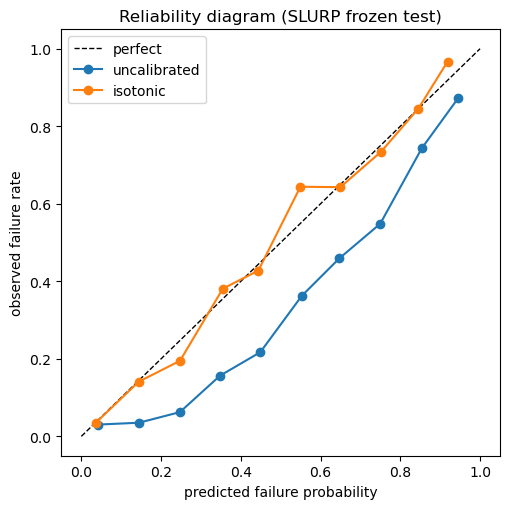

H2: SUPPORTED | ok


In [3]:
# --- H2 verdict + reliability diagram -----------------------------------
bestcal = cal.iloc[0]
improved = bool(bestcal.brier <= brier_score_loss(y, p_uncal) + 1e-4)
h2 = {"best_method": bestcal.method, "ece": float(bestcal.ece), "mce": float(bestcal.mce),
      "brier": float(bestcal.brier), "brier_uncal": float(brier_score_loss(y, p_uncal)),
      "H2_supported": bool(bestcal.ece < 0.05 and improved),
      "H2_note": "MCE high -> tail miscalibration" if bestcal.mce > 0.2 else "ok"}
json.dump(h2, open(OUT / "nb21_h2_summary.json", "w"), indent=2)

fig, ax = plt.subplots(figsize=(5.2, 5.2)); ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
for name in ["uncalibrated", bestcal.method]:
    p = CAL[name]; edges = np.linspace(0, 1, 11); xs, ys = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (p > lo) & (p <= hi)
        if m.sum() > 5: xs.append(p[m].mean()); ys.append(y[m].mean())
    ax.plot(xs, ys, "o-", label=name)
ax.set_xlabel("predicted failure probability"); ax.set_ylabel("observed failure rate")
ax.set_title("Reliability diagram (SLURP frozen test)"); ax.legend(); plt.tight_layout()
plt.savefig(OUT / "nb21_reliability_diagram.png", dpi=140); plt.show()
print("H2:", "SUPPORTED" if h2["H2_supported"] else "PARTIAL", "|", h2["H2_note"])

## H3 — selective prediction

Accept the lowest-risk samples first; defer the rest. A useful risk score gives a
risk-coverage curve well below random and an AURC close to the oracle (low E-AURC).
We compare the model risk against the MSP baseline, the oracle, and random.

In [4]:
risk_model = CAL[bestcal.method]                 # calibration is monotone -> ranking == uncal
risk_msp = 1 - te["intent_confidence"].values
scores = {"model_risk": risk_model, "MSP(1-conf)": risk_msp,
          "oracle": y.astype(float), "random": np.random.default_rng(M.SEED).random(len(y))}
sel = pd.DataFrame([{"score": k, "aurc": M.aurc(y, s), "e_aurc": M.e_aurc(y, s)}
                    for k, s in scores.items()]).sort_values("aurc").reset_index(drop=True)
sel.to_csv(OUT / "nb21_selective_aurc.csv", index=False)

# coverage + accuracy at target risk budgets
cov, sr = M.risk_coverage(y, risk_model); budget_rows = []
for b in (0.01, 0.05, 0.10):
    ok = cov[sr <= b]; c = float(ok.max()) if len(ok) else 0.0
    budget_rows.append({"risk_budget": b, "max_coverage": c, "accepted_accuracy": 1 - b if c else np.nan})
budgets = pd.DataFrame(budget_rows)
budgets.to_csv(OUT / "nb21_coverage_at_risk.csv", index=False)
print(sel.round(4).to_string(index=False)); print(); print(budgets.round(4).to_string(index=False))

      score   aurc  e_aurc
     oracle 0.0245  0.0000
 model_risk 0.0577  0.0332
MSP(1-conf) 0.0826  0.0581
     random 0.2120  0.1875

 risk_budget  max_coverage  accepted_accuracy
        0.01        0.0456               0.99
        0.05        0.6444               0.95
        0.10        0.8117               0.90


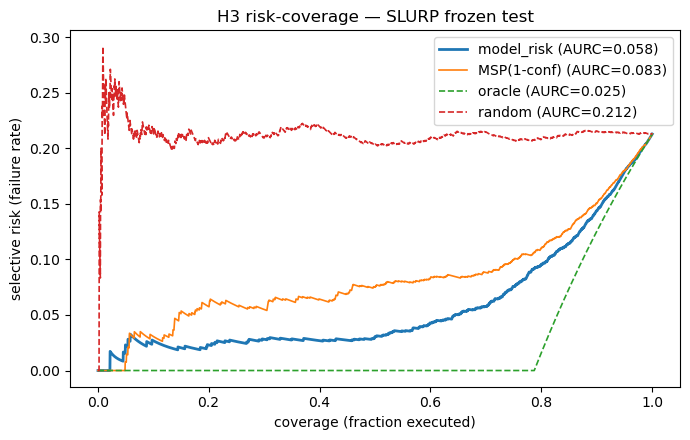

H3: SUPPORTED | beats MSP: True


In [5]:
# --- H3 figure + verdict ------------------------------------------------
plt.figure(figsize=(7, 4.5))
for k, s in scores.items():
    c, r = M.risk_coverage(y, s); plt.plot(c, r, label=f"{k} (AURC={M.aurc(y, s):.3f})",
        lw=2 if k == "model_risk" else 1.2, ls="--" if k in ("oracle", "random") else "-")
plt.xlabel("coverage (fraction executed)"); plt.ylabel("selective risk (failure rate)")
plt.title("H3 risk-coverage — SLURP frozen test"); plt.legend(); plt.tight_layout()
plt.savefig(OUT / "nb21_risk_coverage.png", dpi=140); plt.show()

beats_random = M.aurc(y, risk_model) < M.aurc(y, scores["random"])
beats_msp = M.aurc(y, risk_model) <= M.aurc(y, risk_msp) + 1e-4
h3 = {"aurc_model": M.aurc(y, risk_model), "e_aurc_model": M.e_aurc(y, risk_model),
      "aurc_msp": M.aurc(y, risk_msp), "beats_random": bool(beats_random),
      "beats_or_matches_msp": bool(beats_msp), "H3_supported": bool(beats_random)}
json.dump(h3, open(OUT / "nb21_h3_summary.json", "w"), indent=2)
print("H3:", "SUPPORTED" if h3["H3_supported"] else "NOT SUPPORTED",
      "| beats MSP:", h3["beats_or_matches_msp"])

## Conclusion

Using the risk model persisted by NB20 (`RandomForest` on the three intent-native features), this notebook establishes both deployment properties of the score: it can be post-hoc calibrated, and it drives selective prediction close to the oracle.

**Key results**
- **H2 — SUPPORTED**: isotonic calibration gives ECE = 0.0139, MCE = 0.098, adaptive-ECE = 0.015, and improves Brier 0.115 → 0.097 (uncalibrated ECE = 0.112).
- **H3 — SUPPORTED**: model-risk AURC = 0.058 beats MSP 0.083 and random 0.212, and nears the oracle 0.025 (E-AURC = 0.033).
- Operating points: 64% of traffic auto-executes at a 5% selective-risk budget, 81% at 10%.

**Caveat:** all numbers are in-domain SLURP frozen test — transfer is deferred to NB22; at a strict 1% risk budget coverage collapses to ~4.6%, and temperature scaling alone leaves ECE at 0.093 (isotonic/Platt required).

**Feeds into:** NB22 — H4 cost-sensitive deferral, SLURP→FSC distribution shift, and the final H1–H4 synthesis.